# Popularity Bias Analysis

Notebook de análisis que carga artefactos pre-computados para evitar re-ejecutar la simulación completa.
Ejecuta primero `popularity_bias.ipynb` para generar los artefactos en `../artifacts/`.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().resolve()
if (ROOT / 'src').exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / 'src').exists():
    PROJECT_ROOT = ROOT.parent
elif (ROOT.parent.parent / 'src').exists():
    PROJECT_ROOT = ROOT.parent.parent
else:
    raise RuntimeError("Could not find project root")

sys.path.insert(0, str(PROJECT_ROOT))

from src.eval.simulation_metrics import evaluate_run_awpd_observations, evaluate_run_quality_observations

type = "Bipolar"
ARTIFACTS = PROJECT_ROOT / "artifacts" / type
assert ARTIFACTS.exists(), f"Artifacts dir not found: {ARTIFACTS}. Run the simulation notebook first."

## Cargar artefactos

In [2]:
ratings_long = pd.read_parquet(ARTIFACTS / "ratings_long.parquet")

# detect models from parquet files
model_names = sorted(set(
    f.stem.rsplit("_run", 1)[0].replace("ratings_", "", 1)
    for f in ARTIFACTS.glob("ratings_*_run*.parquet")
))

# detect number of runs per model
ratings_by_model = {}
for name in model_names:
    runs = sorted(ARTIFACTS.glob(f"ratings_{name}_run*.parquet"), key=lambda f: int(f.stem.rsplit("run", 1)[1]))
    ratings_by_model[name] = [pd.read_parquet(f) for f in runs]

with np.load(ARTIFACTS / "simulation_state.npz") as data:
    uc         = data["user_clusters"]
    ic         = data["item_clusters"]
    A          = data["affinity"]
    popularity = data["popularity"]
    U          = int(data["num_users"][0])

rmse_df = pd.read_parquet(ARTIFACTS / "rmse.parquet")

print("ratings_long:", ratings_long.shape)
print("models:", list(ratings_by_model.keys()))
print("runs per model:", {m: len(v) for m, v in ratings_by_model.items()})
print("U:", U, "| uc shape:", uc.shape, "| ic shape:", ic.shape)
print("rmse_df:", rmse_df.shape)

ratings_long: (252300, 3)
models: ['BaselineOnly', 'CF User-Pearson', 'Popularity', 'Random', 'SVD', 'SVDpp']
runs per model: {'BaselineOnly': 40, 'CF User-Pearson': 40, 'Popularity': 40, 'Random': 40, 'SVD': 40, 'SVDpp': 40}
U: 3000 | uc shape: (3000,) | ic shape: (1682,)
rmse_df: (240, 3)


## Calcular AWPD

In [3]:
obs_df = evaluate_run_awpd_observations(
    ratings_long=ratings_long,
    ratings_by_model=ratings_by_model,
    user_clusters=uc,
    item_clusters=ic,
    affinity=A,
    num_users=U,
    popularity=popularity,
)

# merge RMSE into obs_df (one RMSE value per Model/Run broadcast to all users)
obs_df = obs_df.merge(rmse_df, on=["Model", "Run"], how="left")

# aggregated view: one row per (Model, Run)
awpd_df = obs_df.groupby(["Model", "Run"])[["AWPD", "UPD", "Misalignment", "RMSE"]].mean().reset_index()

print("obs_df:", obs_df.shape)
obs_df.head(5)

obs_df: (720000, 7)


,Model,Run,UserID,AWPD,UPD,Misalignment,RMSE
0,BaselineOnly,0,0,0.647655,0.233257,0.604192,0.704364
1,BaselineOnly,0,1,0.530899,0.318135,0.425022,0.704364
2,BaselineOnly,0,2,0.524468,0.212820,0.479347,0.704364
3,BaselineOnly,0,3,0.666366,0.397590,0.534758,0.704364
4,BaselineOnly,0,4,0.527077,0.219170,0.479347,0.704364


In [4]:
print(obs_df.shape)
obs_df[obs_df["Model"] == "Random"].head(10)

(720000, 7)


,Model,Run,UserID,AWPD,UPD,Misalignment,RMSE
360000,Random,0,0,0.591303,0.281721,0.519877,1.617323
360001,Random,0,1,0.480943,0.241262,0.416051,1.617323
360002,Random,0,2,0.603279,0.389848,0.460395,1.617323
360003,Random,0,3,0.685185,0.292413,0.619656,1.617323
360004,Random,0,4,0.661493,0.402218,0.525160,1.617323
360005,Random,0,5,0.630678,0.359083,0.518473,1.617323
360006,Random,0,6,0.629200,0.337712,0.530889,1.617323
360007,Random,0,7,0.702615,0.338712,0.615583,1.617323
360008,Random,0,8,0.715366,0.295000,0.651709,1.617323
360009,Random,0,9,0.525445,0.271692,0.449751,1.617323


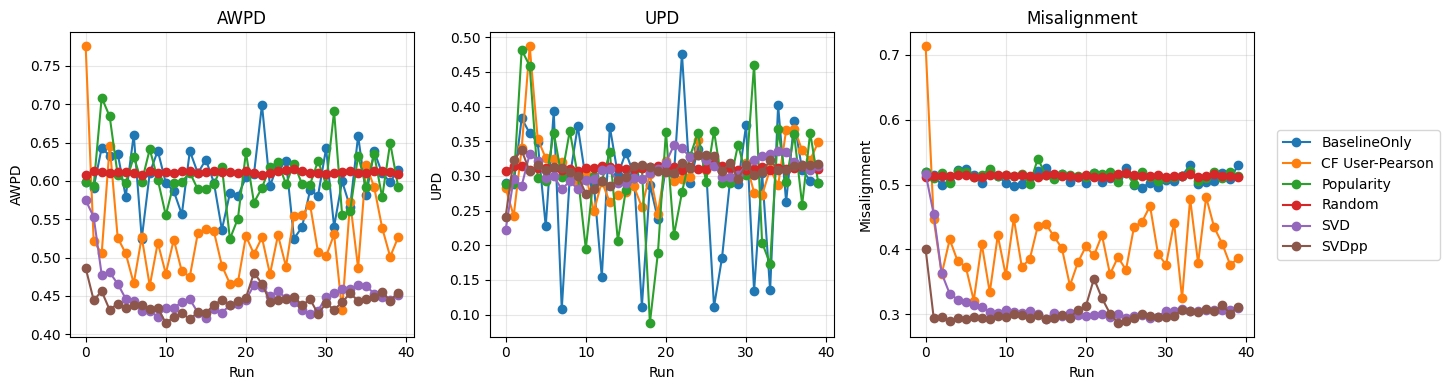

In [5]:
awpd_metrics_to_plot = ["AWPD", "UPD", "Misalignment"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, metric in zip(axes, awpd_metrics_to_plot):
    for model, sub in awpd_df.groupby("Model"):
        sub = sub.sort_values("Run")
        ax.plot(sub["Run"], sub[metric], marker="o", label=model)
    ax.set_title(metric)
    ax.set_xlabel("Run")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(.85, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

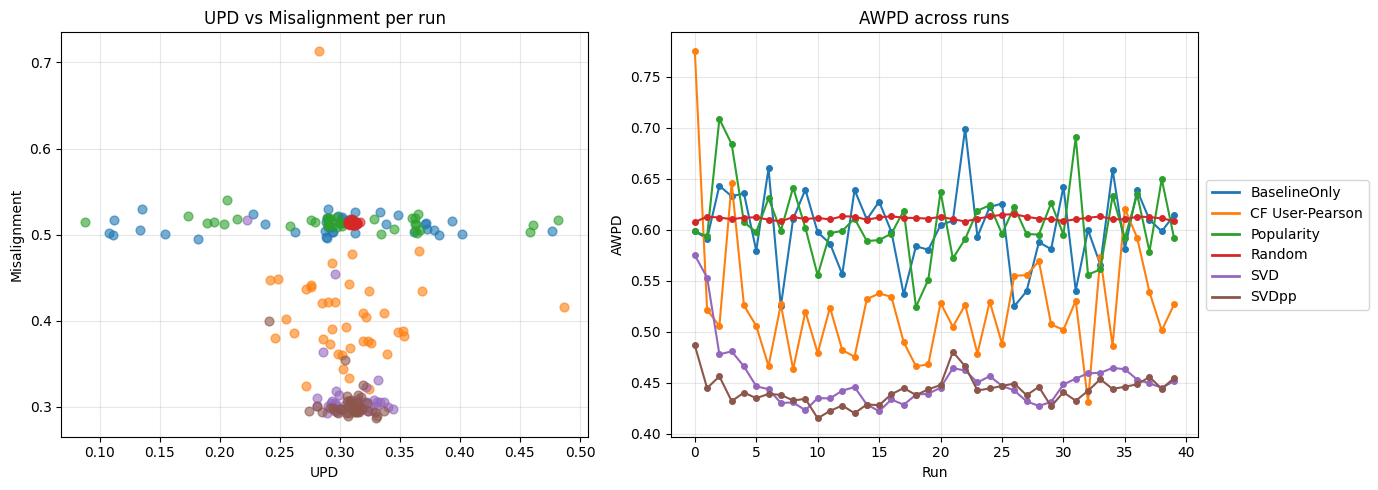

In [6]:
from matplotlib.lines import Line2D

models = sorted(awpd_df["Model"].unique())
palette = {m: c for m, c in zip(models, plt.cm.tab10.colors)}

fig, (ax_scatter, ax_awpd) = plt.subplots(1, 2, figsize=(14, 5))

# --- left: UPD vs Misalignment scatter (one point per run) ---
for model in models:
    sub = awpd_df[awpd_df["Model"] == model]
    ax_scatter.scatter(sub["UPD"], sub["Misalignment"],
                       color=palette[model], alpha=0.6, s=40, zorder=3)

ax_scatter.set_xlabel("UPD")
ax_scatter.set_ylabel("Misalignment")
ax_scatter.set_title("UPD vs Misalignment per run")
ax_scatter.grid(True, alpha=0.3)

# --- right: AWPD across runs ---
for model in models:
    sub = awpd_df[awpd_df["Model"] == model].sort_values("Run")
    ax_awpd.plot(sub["Run"], sub["AWPD"], marker="o", markersize=4,
                 label=model, color=palette[model])

ax_awpd.set_xlabel("Run")
ax_awpd.set_ylabel("AWPD")
ax_awpd.set_title("AWPD across runs")
ax_awpd.grid(True, alpha=0.3)

legend_handles = [Line2D([0], [0], color=palette[m], linewidth=2, label=m) for m in models]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(.86, 0.5))
plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()


## RMSE vs AWPD

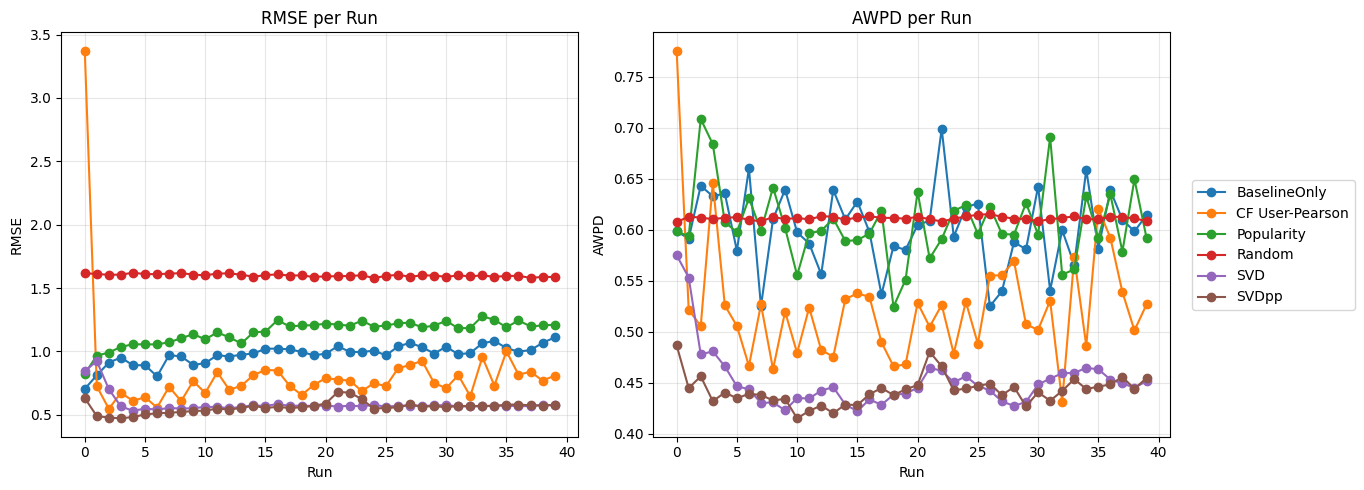

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for model, sub in awpd_df.groupby("Model"):
    sub = sub.sort_values("Run")
    ax1.plot(sub["Run"], sub["RMSE"], marker="o", label=model)
ax1.set_title("RMSE per Run")
ax1.set_xlabel("Run")
ax1.set_ylabel("RMSE")
ax1.grid(True, alpha=0.3)

for model, sub in awpd_df.groupby("Model"):
    sub = sub.sort_values("Run")
    ax2.plot(sub["Run"], sub["AWPD"], marker="o", label=model)
ax2.set_title("AWPD per Run")
ax2.set_xlabel("Run")
ax2.set_ylabel("AWPD")
ax2.grid(True, alpha=0.3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(.85, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## UPD vs Misalignment

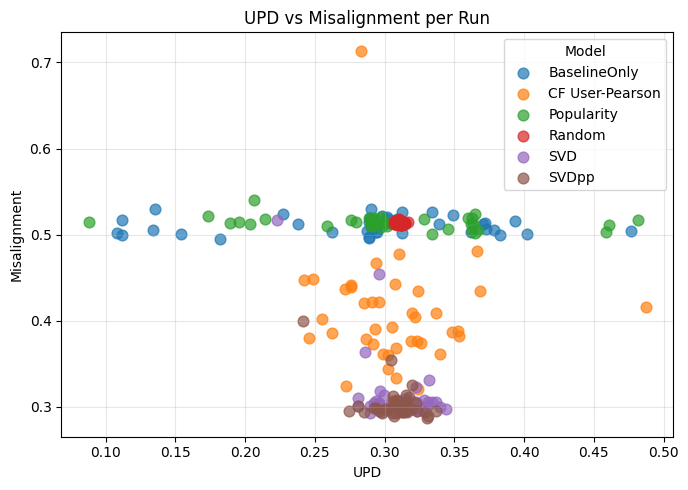

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, sub in awpd_df.groupby("Model"):
    ax.scatter(sub["UPD"], sub["Misalignment"], label=model, alpha=0.70, s=60)

ax.set_xlabel("UPD")
ax.set_ylabel("Misalignment")
ax.set_title("UPD vs Misalignment per Run")
ax.legend(title="Model")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

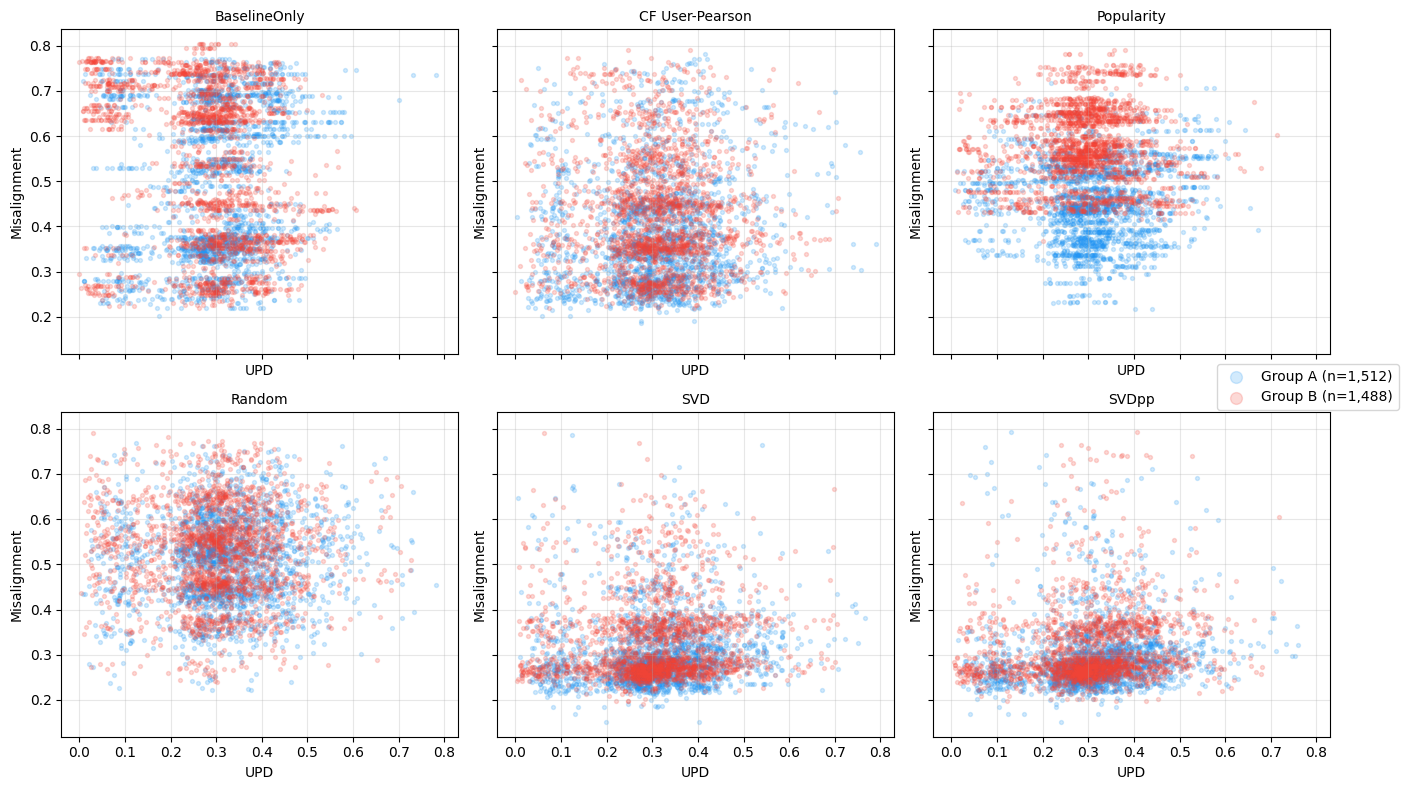

In [9]:
from sklearn.cluster import KMeans

# cluster user-cluster rows of A into 2 groups (works for bipolar AND outliers)
km = KMeans(n_clusters=2, random_state=42, n_init=10)
group_of_cluster = km.fit_predict(A)  # (n_user_clusters,)

# label the smaller group as 'Outlier/Minority' if sizes differ, else 'Group A/B'
counts = np.bincount(group_of_cluster)
minority = int(np.argmin(counts))
majority = int(np.argmax(counts))
if counts[minority] < 0.4 * counts[majority]:  # clearly unequal -> outlier structure
    group_labels = {majority: "Normal", minority: "Outlier"}
    group_colors = {majority: "#2196F3", minority: "#F44336"}
else:  # roughly equal -> bipolar structure
    group_labels = {0: "Group A", 1: "Group B"}
    group_colors = {0: "#2196F3", 1: "#F44336"}

user_group_series = pd.Series(group_of_cluster[uc])  # indexed by UserID 0..U-1
user_counts = user_group_series.value_counts().to_dict()  # {group_id: num_users}
obs_group = obs_df.copy()
obs_group["Group"] = obs_group["UserID"].map(user_group_series)

models = sorted(obs_group["Model"].unique())
cols = 3
rows = (len(models) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model in zip(axes, models):
    sub = obs_group[obs_group["Model"] == model]
    for g in sorted(group_labels):
        g_sub = sub[sub["Group"] == g].sample(min(2000, (sub["Group"] == g).sum()), random_state=42)
        label = f"{group_labels[g]} (n={user_counts.get(g, 0):,})"
        ax.scatter(g_sub["UPD"], g_sub["Misalignment"],
                   color=group_colors[g], alpha=0.2, s=8,
                   label=label, rasterized=True)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel("UPD")
    ax.set_ylabel("Misalignment")
    ax.grid(True, alpha=0.3)

for ax in axes[len(models):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(.81, 0.51), markerscale=3)
scenario_label = type if 'type' in dir() else 'current scenario'
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


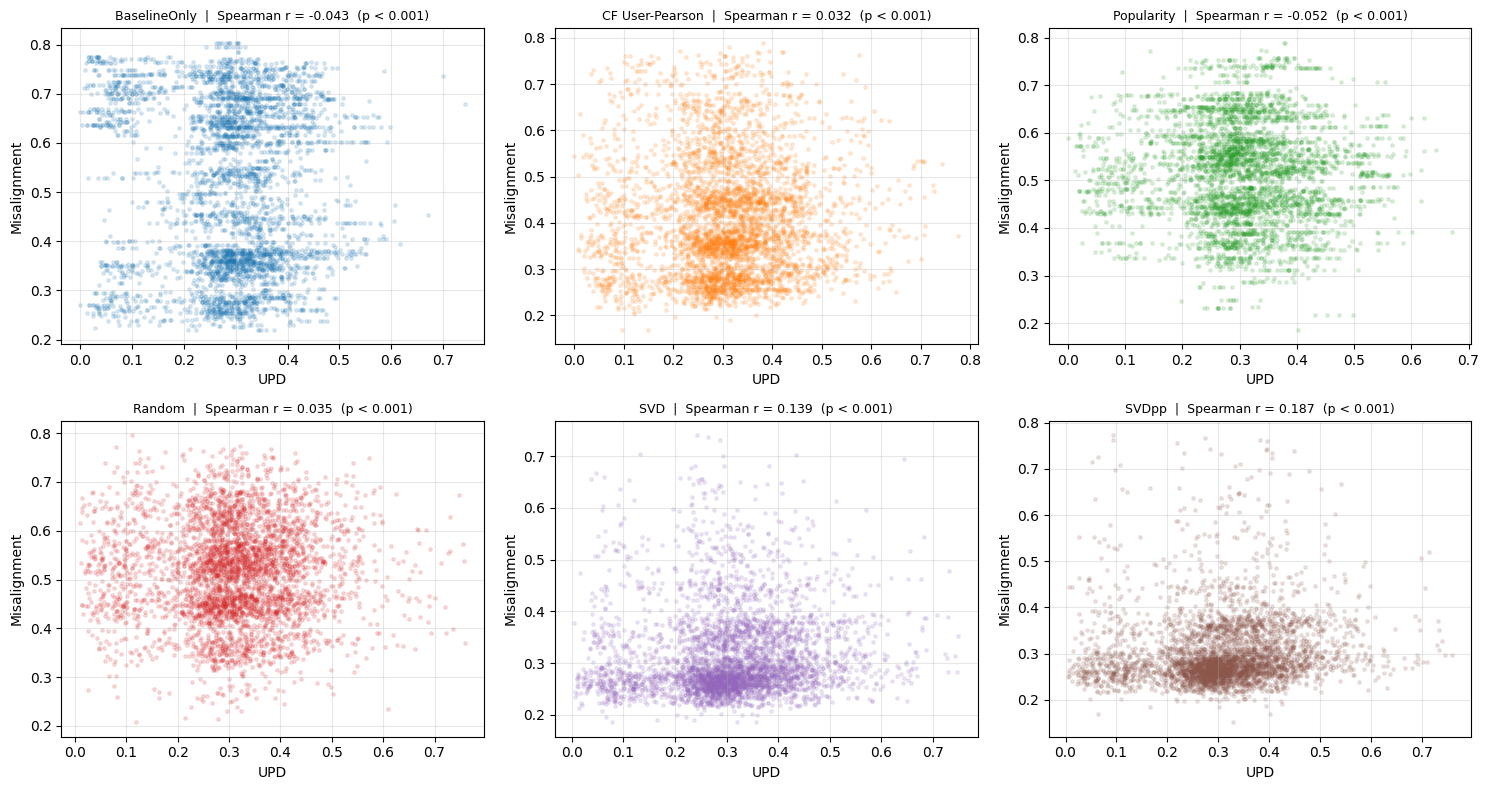

In [10]:
from scipy.stats import spearmanr

models = sorted(obs_df["Model"].unique())
palette = {m: c for m, c in zip(models, plt.cm.tab10.colors)}

cols = 3
rows = (len(models) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    sub = obs_df[obs_df["Model"] == model]
    r, p = spearmanr(sub["UPD"], sub["Misalignment"])
    p_str = "< 0.001" if p < 0.001 else f"= {p:.3f}"
    title = f"{model}  |  Spearman r = {r:.3f}  (p {p_str})"

    sample = sub.sample(min(4000, len(sub)), random_state=42)
    ax.scatter(sample["UPD"], sample["Misalignment"],
               color=palette[model], alpha=0.15, s=6, rasterized=True)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("UPD")
    ax.set_ylabel("Misalignment")
    ax.grid(True, alpha=0.3)

for ax in axes[len(models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


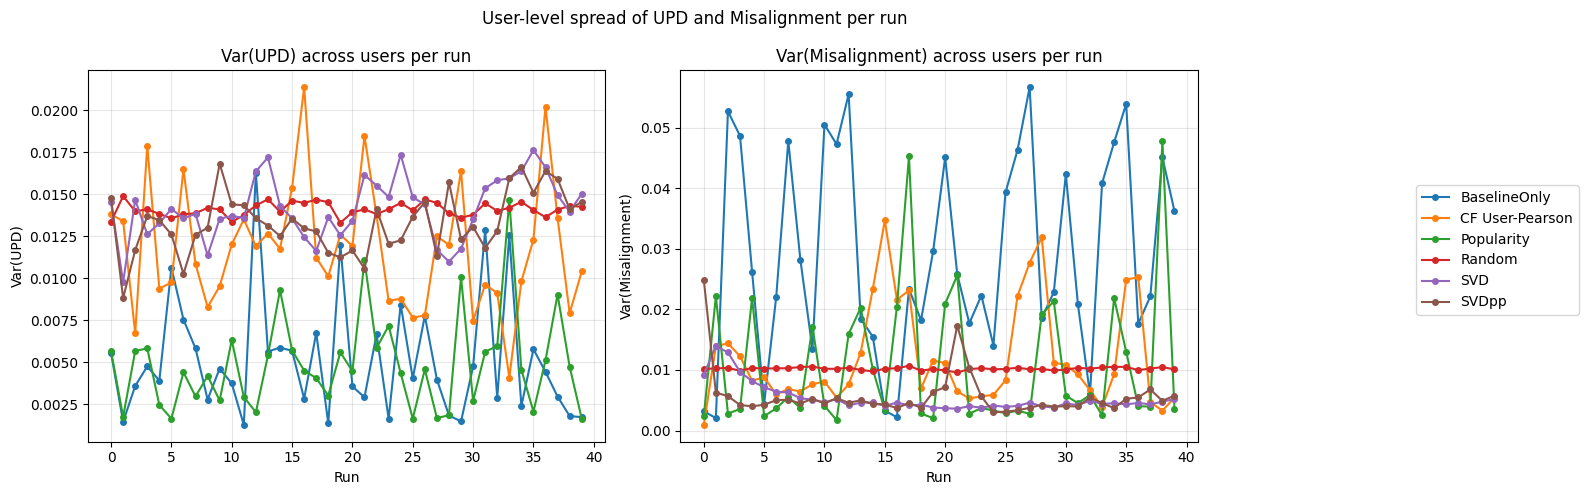

In [11]:
# variance across users per run
var_run_df = (
    obs_df.groupby(["Model", "Run"])[["UPD", "Misalignment"]]
    .var()
    .reset_index()
)

models = sorted(var_run_df["Model"].unique())
palette = {m: c for m, c in zip(models, plt.cm.tab10.colors)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, metric in zip(axes, ["UPD", "Misalignment"]):
    for model in models:
        sub = var_run_df[var_run_df["Model"] == model].sort_values("Run")
        ax.plot(sub["Run"], sub[metric], marker="o", label=model,
                color=palette[model], markersize=4)
    ax.set_title(f"Var({metric}) across users per run")
    ax.set_xlabel("Run")
    ax.set_ylabel(f"Var({metric})")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.suptitle("User-level spread of UPD and Misalignment per run", fontsize=12)
plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()


C:\Users\mrari\AppData\Local\Temp\ipykernel_25880\3709704464.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(np.unique(uc)))


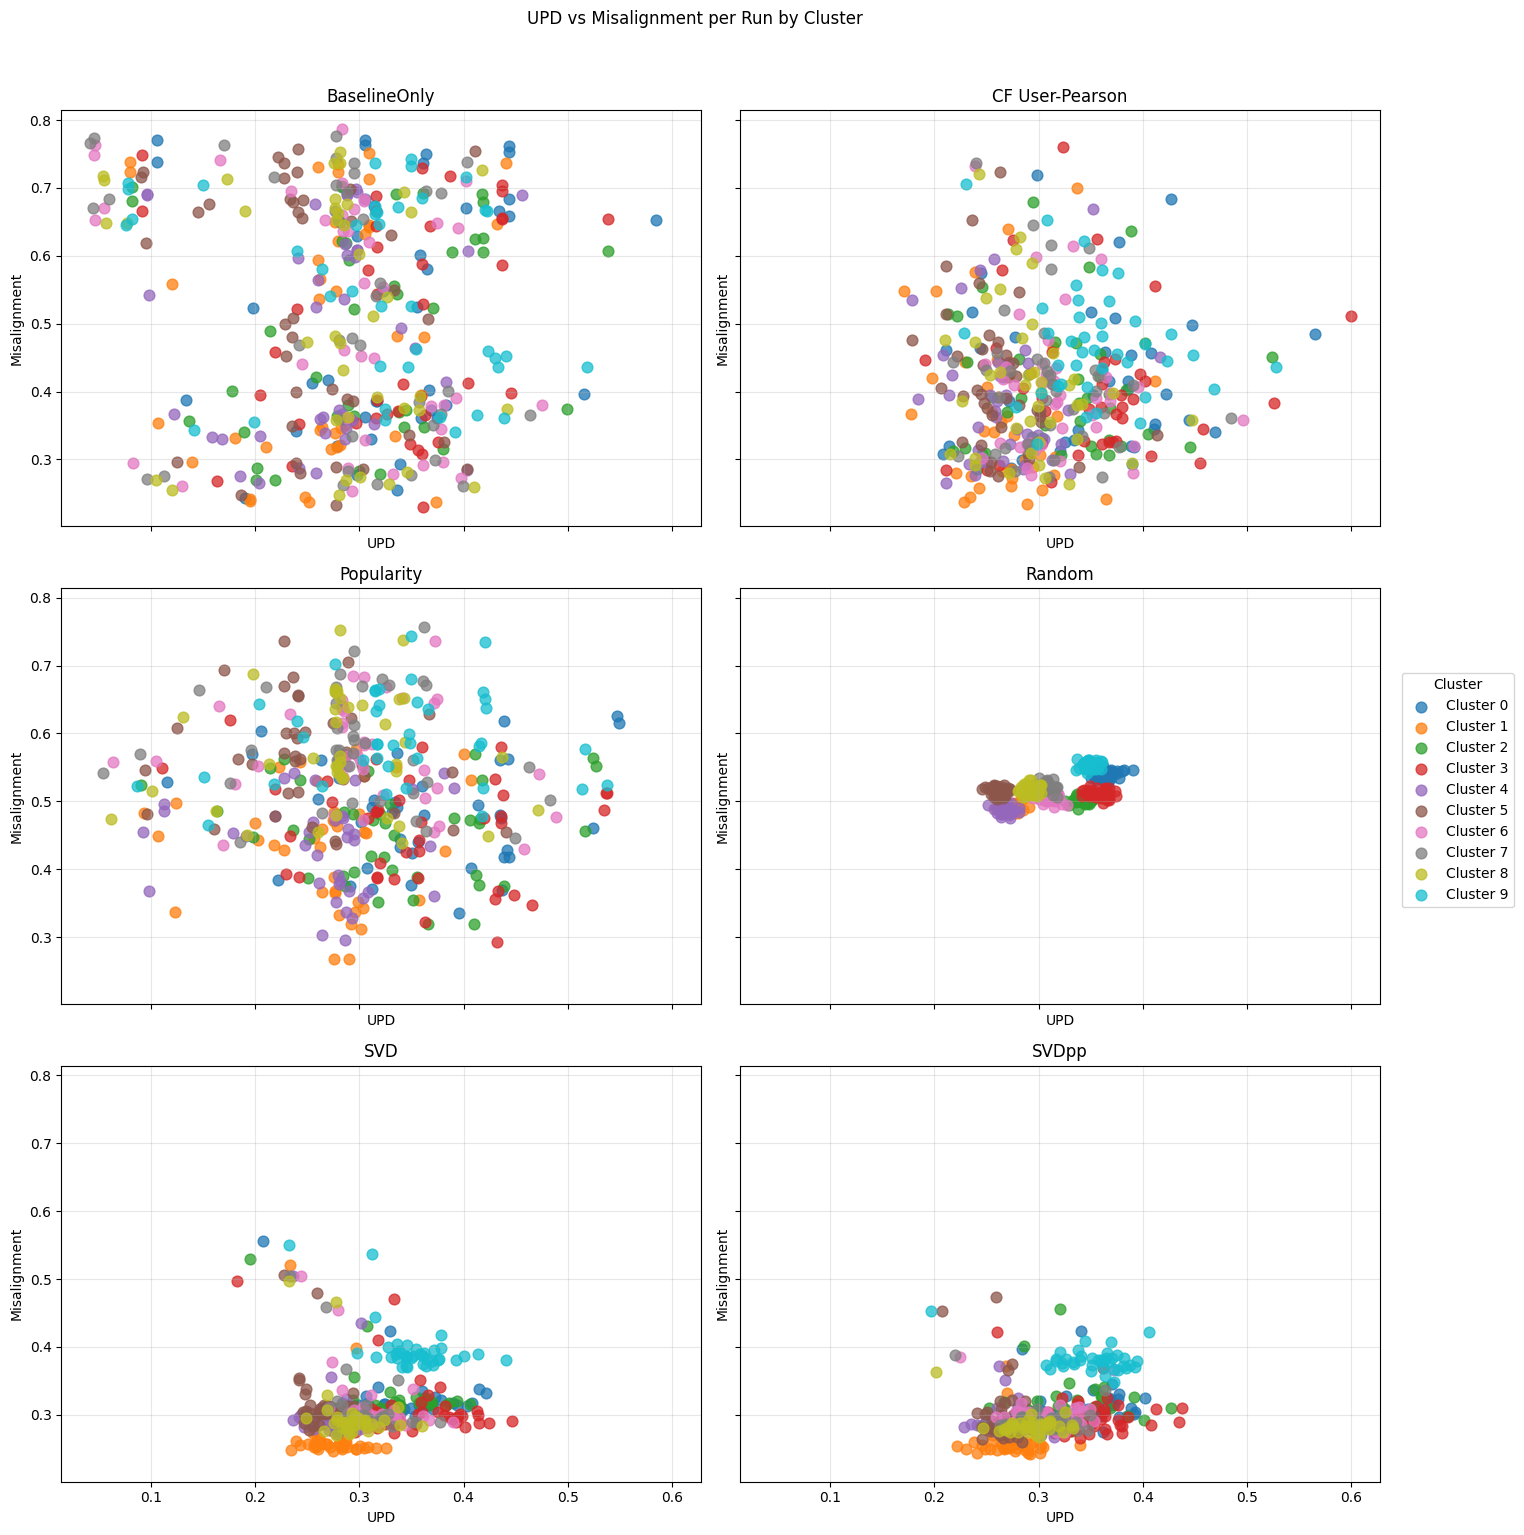

In [12]:
models = list(ratings_by_model.keys())
n = len(models)
cols = 2
rows = (n + 1) // cols
cmap = plt.cm.get_cmap("tab10", len(np.unique(uc)))

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model in zip(axes, models):
    model_obs = obs_df[obs_df["Model"] == model].copy()
    model_obs["Cluster"] = uc[model_obs["UserID"].values]
    cluster_df = (
        model_obs
        .groupby(["Run", "Cluster"])[["UPD", "Misalignment"]]
        .mean()
        .reset_index()
    )
    for i, c in enumerate(sorted(cluster_df["Cluster"].unique())):
        sub = cluster_df[cluster_df["Cluster"] == c]
        ax.scatter(sub["UPD"], sub["Misalignment"],
                   label=f"Cluster {c}", color=cmap(i), alpha=0.75, s=60)
    ax.set_title(model)
    ax.set_xlabel("UPD")
    ax.set_ylabel("Misalignment")
    ax.grid(True, alpha=0.3)

for ax in axes[len(models):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Cluster", loc="center right", bbox_to_anchor=(1.09, 0.5))
plt.suptitle("UPD vs Misalignment per Run by Cluster", y=1.02)
plt.tight_layout()
plt.show()


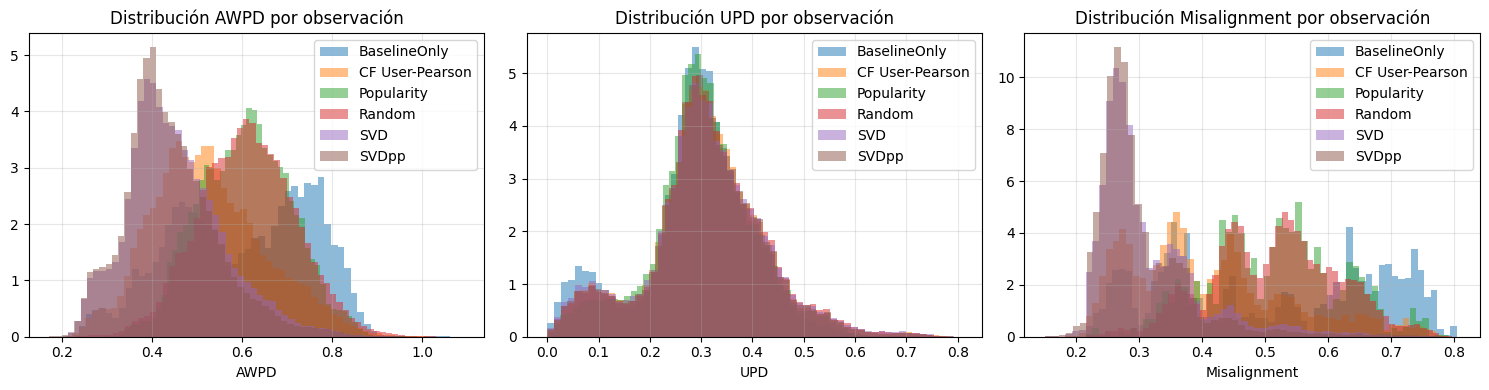

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["AWPD", "UPD", "Misalignment"]):
    for model, sub in obs_df.groupby("Model"):
        ax.hist(sub[metric], bins=60, alpha=0.5, label=model, density=True)
    ax.set_title(f"Distribución {metric} por observación")
    ax.set_xlabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calcular Novelty, Relevance, Diversity

In [14]:
quality_df = evaluate_run_quality_observations(
    ratings_long=ratings_long,
    ratings_by_model=ratings_by_model,
    num_users=U,
    num_items=len(ic),
)

quality_agg = quality_df.groupby(["Model", "Run"])[["Novelty", "Relevance", "Diversity"]].mean().reset_index()

print("quality_df:", quality_df.shape)
quality_df.head(5)

quality_df: (720000, 6)


,Model,Run,UserID,Novelty,Relevance,Diversity
0,BaselineOnly,0,0,3.740868,4.4,0.922017
1,BaselineOnly,0,1,4.008224,4.8,0.944851
2,BaselineOnly,0,2,4.008224,4.2,0.944851
3,BaselineOnly,0,3,4.046876,4.2,0.947273
4,BaselineOnly,0,4,4.008224,4.0,0.944851


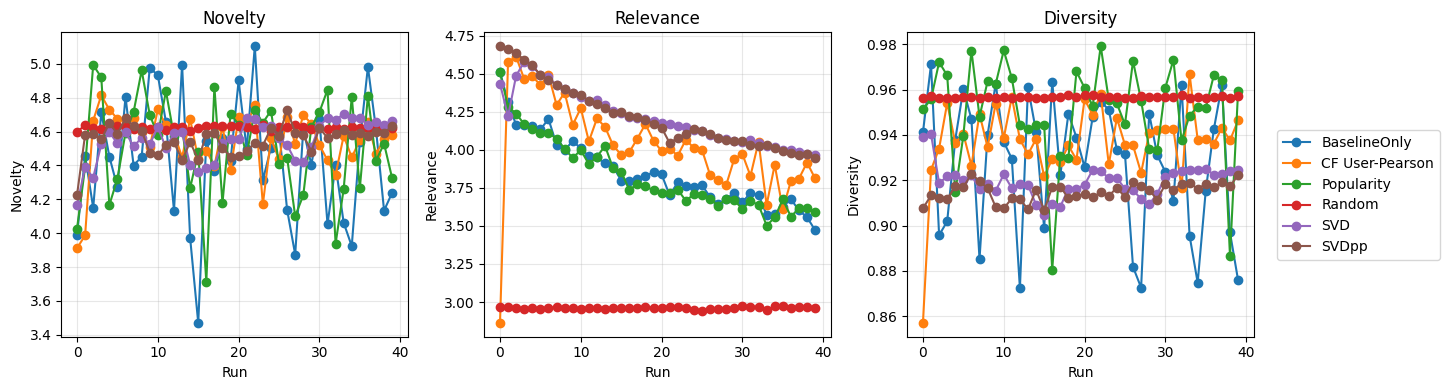

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, metric in zip(axes, ["Novelty", "Relevance", "Diversity"]):
    for model, sub in quality_agg.groupby("Model"):
        sub = sub.sort_values("Run")
        ax.plot(sub["Run"], sub[metric], marker="o", label=model)
    ax.set_title(metric)
    ax.set_xlabel("Run")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(.85, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


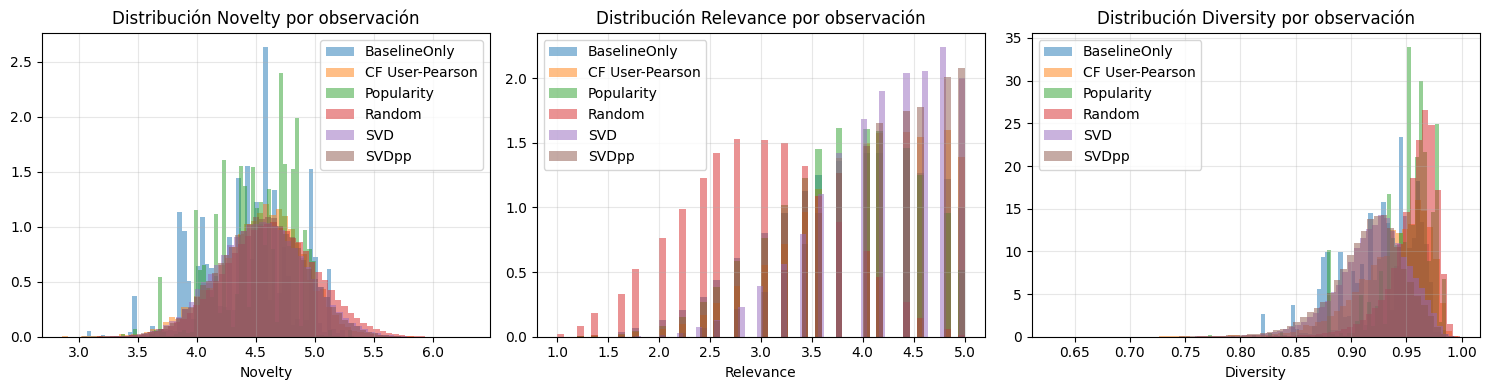

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["Novelty", "Relevance", "Diversity"]):
    for model, sub in quality_df.groupby("Model"):
        ax.hist(sub[metric], bins=60, alpha=0.5, label=model, density=True)
    ax.set_title(f"Distribución {metric} por observación")
    ax.set_xlabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Novelty vs AWPD

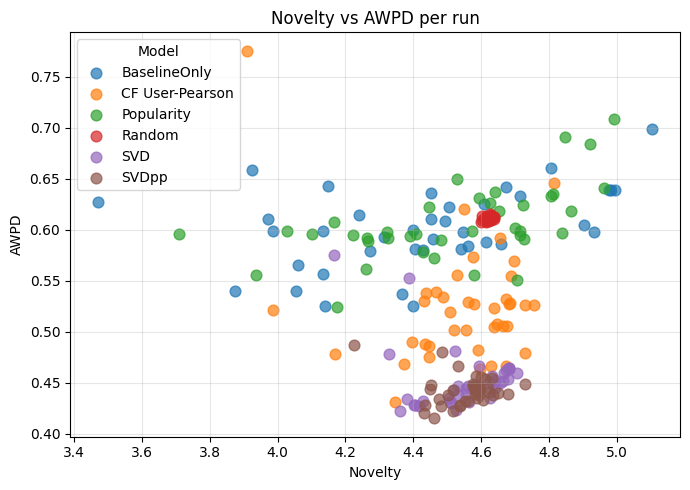

In [17]:
merged = awpd_df.merge(quality_agg, on=["Model", "Run"])

fig, ax = plt.subplots(figsize=(7, 5))
for model, sub in merged.groupby("Model"):
    ax.scatter(sub["Novelty"], sub["AWPD"], label=model, alpha=0.70, s=60)
ax.set_xlabel("Novelty")
ax.set_ylabel("AWPD")
ax.set_title("Novelty vs AWPD per run")
ax.legend(title="Model")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


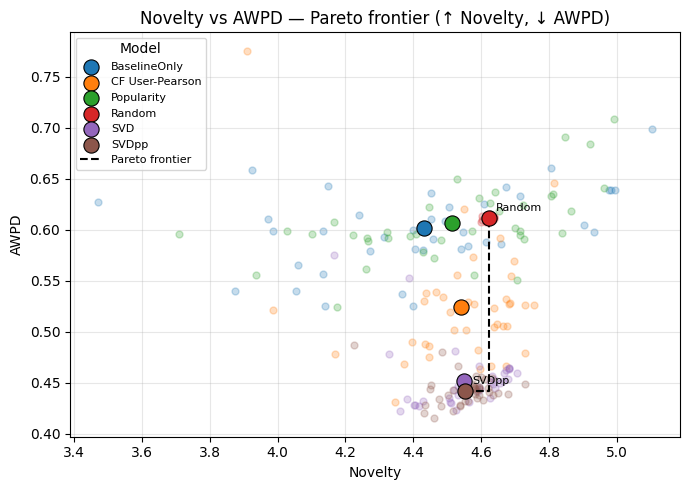

In [18]:
# Per-model mean across runs
model_means = merged.groupby("Model")[["AWPD", "Novelty"]].mean().reset_index()

def _pareto_mask(df, x_col, y_col):
    """True for points not dominated (maximize x, minimize y)."""
    pts = df[[x_col, y_col]].to_numpy()
    mask = np.ones(len(pts), dtype=bool)
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i == j:
                continue
            if xj >= xi and yj <= yi and (xj > xi or yj < yi):
                mask[i] = False
                break
    return mask

frontier = model_means[_pareto_mask(model_means, "Novelty", "AWPD")].sort_values("Novelty")

MODEL_COLORS = {
    name: color
    for name, color in zip(sorted(merged["Model"].unique()), plt.cm.tab10.colors)
}

fig, ax = plt.subplots(figsize=(7, 5))

# individual run points (faded)
for model, sub in merged.groupby("Model"):
    ax.scatter(sub["Novelty"], sub["AWPD"],
               color=MODEL_COLORS[model], alpha=0.25, s=25)

# model means (bold markers)
for _, row in model_means.iterrows():
    ax.scatter(row["Novelty"], row["AWPD"],
               color=MODEL_COLORS[row["Model"]], s=120,
               edgecolors="black", linewidths=0.8,
               zorder=5, label=row["Model"])

# Pareto frontier staircase
xs, ys = [], []
for _, row in frontier.iterrows():
    if xs:
        xs.append(row["Novelty"])
        ys.append(ys[-1])
    xs.append(row["Novelty"])
    ys.append(row["AWPD"])
ax.plot(xs, ys, color="black", linewidth=1.5, linestyle="--",
        label="Pareto frontier", zorder=4)

# annotate frontier models
for _, row in frontier.iterrows():
    ax.annotate(row["Model"], (row["Novelty"], row["AWPD"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Novelty")
ax.set_ylabel("AWPD")
ax.set_title("Novelty vs AWPD — Pareto frontier (↑ Novelty, ↓ AWPD)")
ax.legend(title="Model", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Popularity Bias — Gini & Lorenz

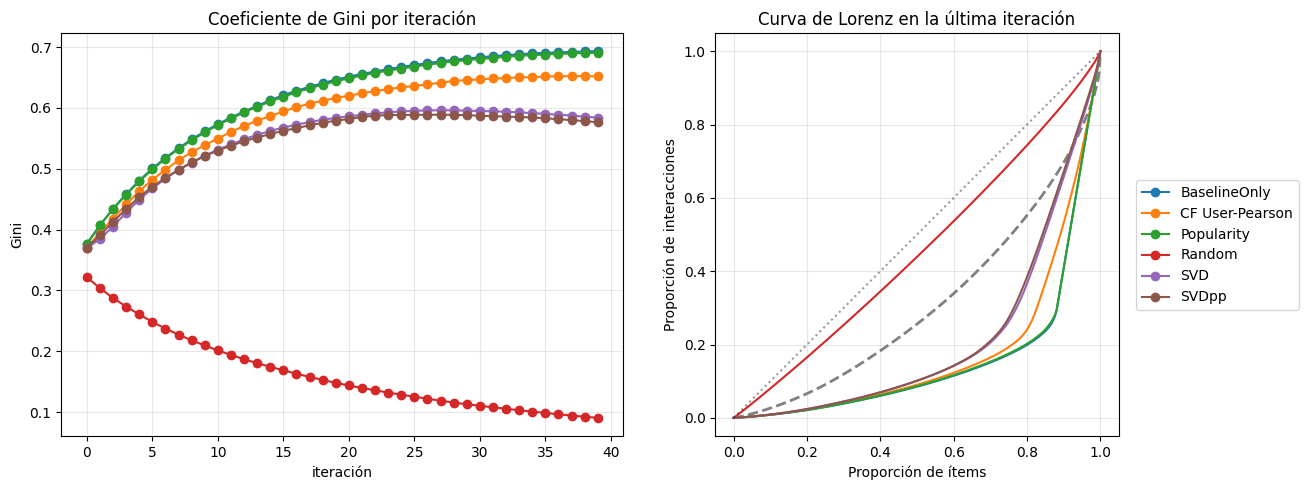

,model,run,gini_cnt,delta_gini_cnt,top10_share,top100_share
0,Base,-1,0.376562,NaN,0.076079,0.227116
1,BaselineOnly,0,0.376562,0.000000,0.101766,0.227116
2,BaselineOnly,1,0.407187,0.030625,0.138771,0.263634
3,BaselineOnly,2,0.434315,0.057754,0.169310,0.296404
4,BaselineOnly,3,0.458384,0.081823,0.192123,0.325319
...,...,...,...,...,...,...
236,SVDpp,35,0.583004,0.212989,0.056055,0.217895
237,SVDpp,36,0.581484,0.211469,0.055506,0.214648
238,SVDpp,37,0.580041,0.210026,0.055182,0.211896
239,SVDpp,38,0.578348,0.208333,0.054704,0.208880


In [19]:
from src.utils.popularity import popularity_analysis
popularity_analysis(ratings_by_model, gini_only=True)
